# 1 - create a binary classifier to detect this kind of Iris using LinearSVC from sklearn.

Prediction : [False  True False False False  True False False False False False  True
  True  True  True False False False False False  True False  True False
 False False False False  True  True]
Iris-setosa
precision : 1.0
Recall : 1.0


/home/wecode/rendu/C-DAT-600-ABJ-2-1-ml01-9/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


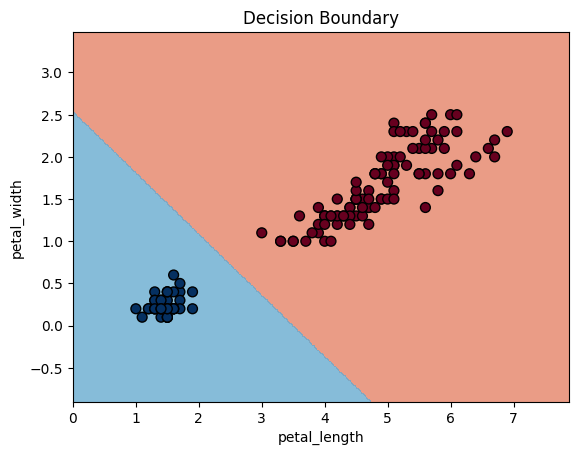

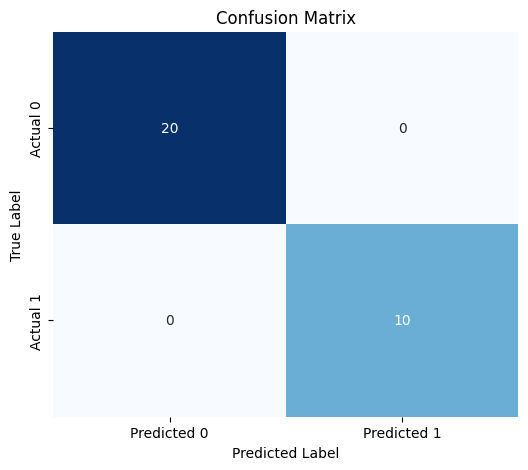

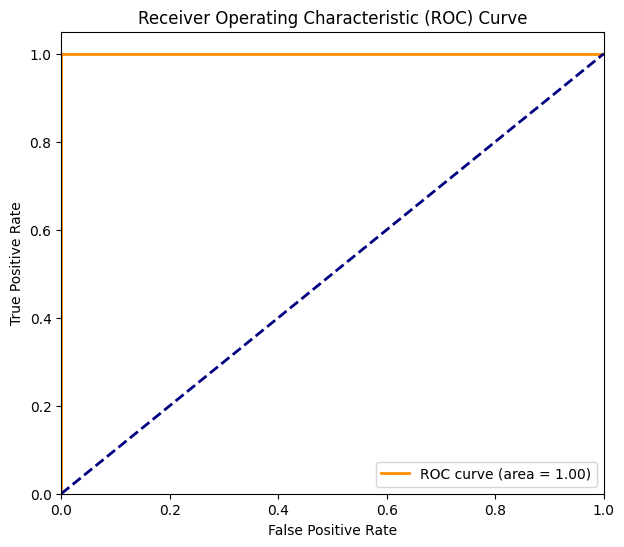

**********************Standard Scaler***************************
Prediction : [False  True False False False  True False False False False False  True
  True  True  True False False False False False  True False  True False
 False False False False  True  True]


/home/wecode/rendu/C-DAT-600-ABJ-2-1-ml01-9/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


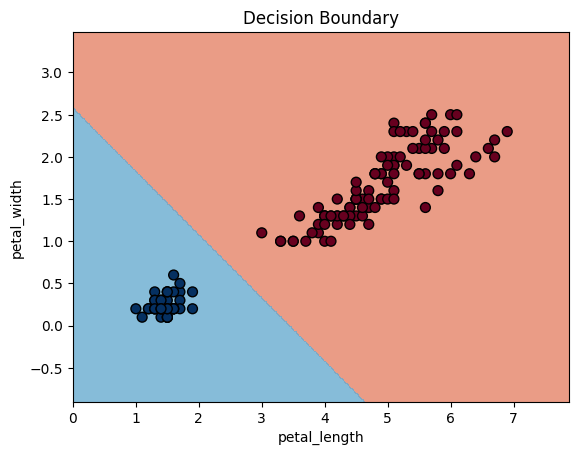

Precision : 1.0
Recall score : 1.0


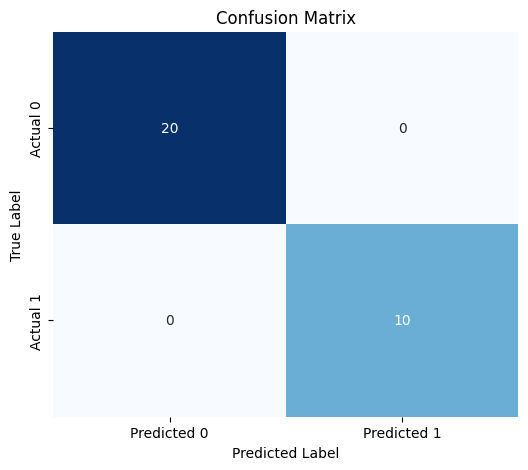

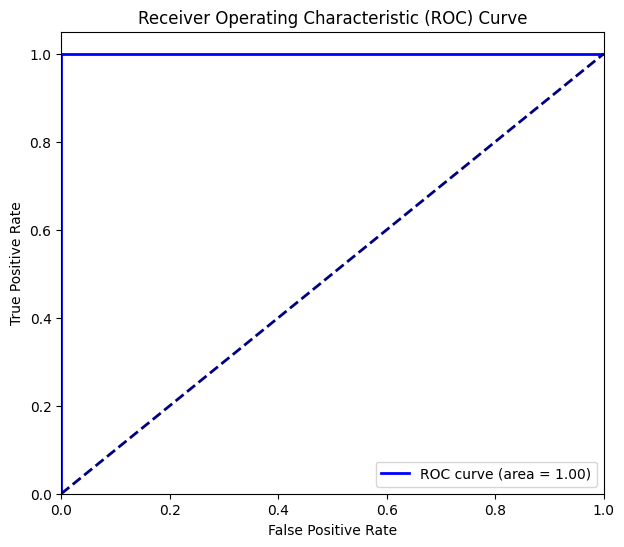

****************End******************
Prediction : [False False  True False False False False  True False False  True False
 False False False False  True False False  True False  True False  True
  True  True  True  True False False]
Iris-virginica
precision : 1.0
Recall : 1.0


/home/wecode/rendu/C-DAT-600-ABJ-2-1-ml01-9/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


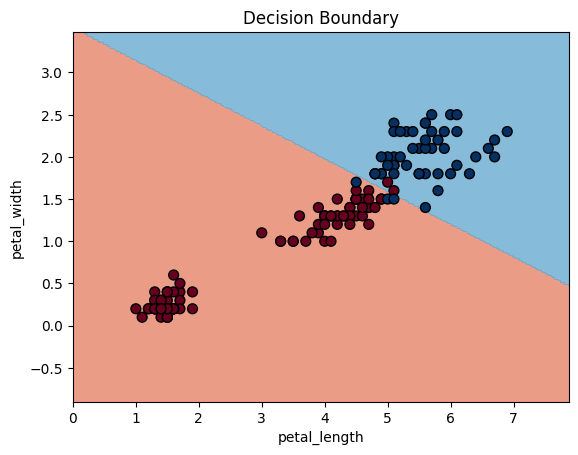

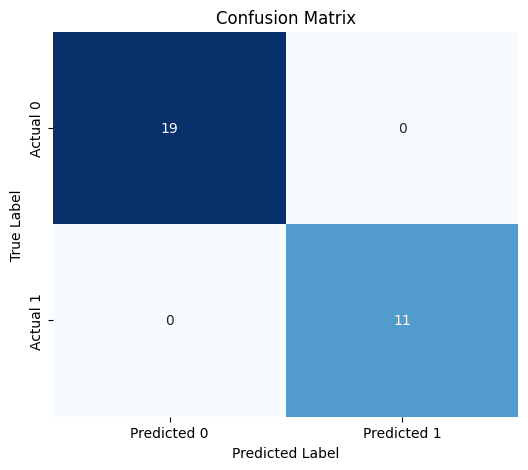

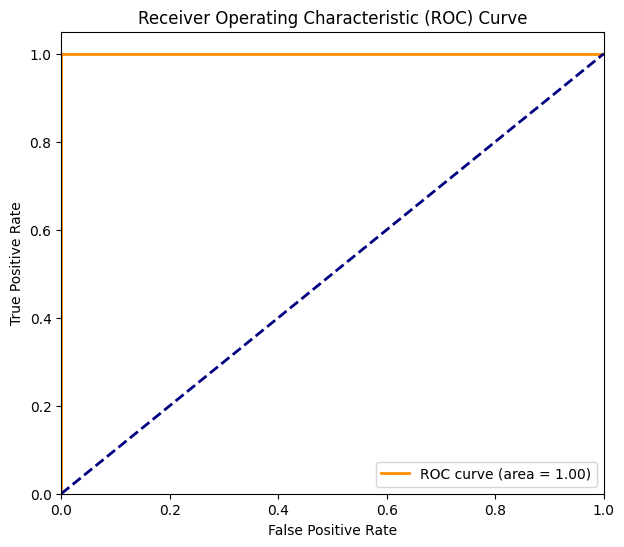

**********************Standard Scaler***************************


/home/wecode/rendu/C-DAT-600-ABJ-2-1-ml01-9/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


Prediction : [False False  True False False False False  True False False  True False
 False False False False  True False False  True False  True False  True
  True  True  True  True False False]


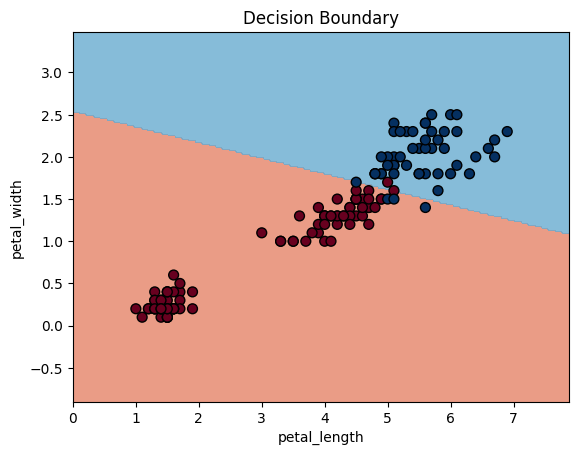

Precision : 1.0
Recall score : 1.0


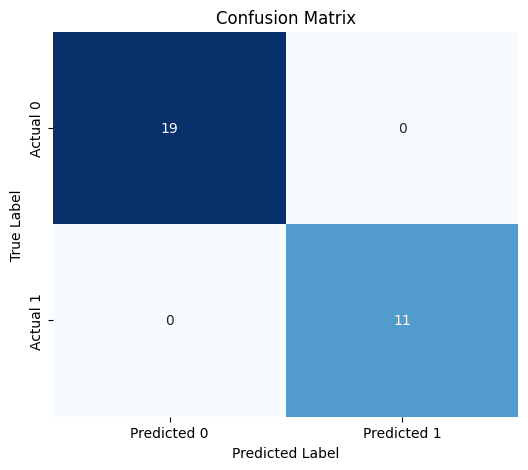

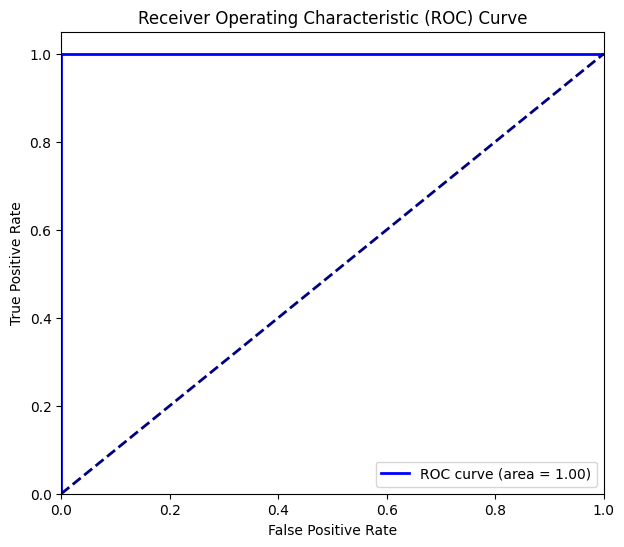

****************End******************
Prediction : [ True False  True False  True False False False False False False False
 False False False False False False  True False False False False False
  True False  True False False False]
Iris-versicolor
precision : 0.5
Recall : 0.3333333333333333


/home/wecode/rendu/C-DAT-600-ABJ-2-1-ml01-9/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


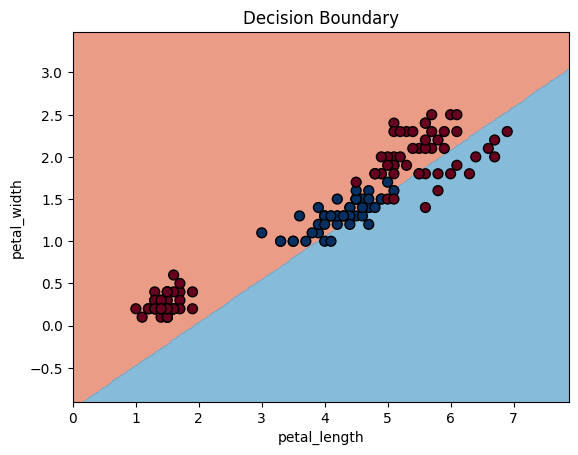

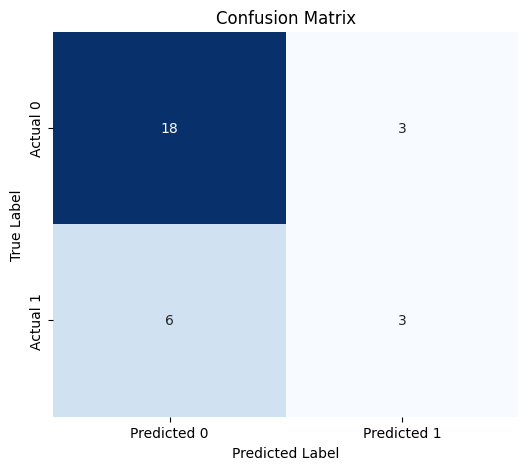

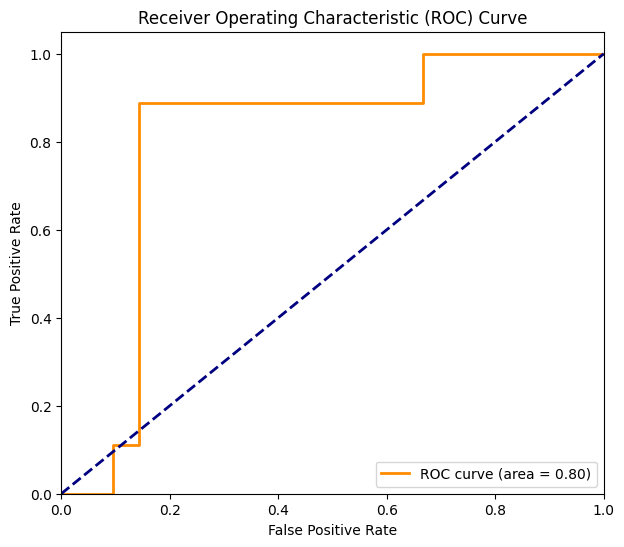

**********************Standard Scaler***************************
Prediction : [ True False  True False  True False False False False False False False
 False False False False False False False False False False False False
  True False  True False False False]


/home/wecode/rendu/C-DAT-600-ABJ-2-1-ml01-9/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


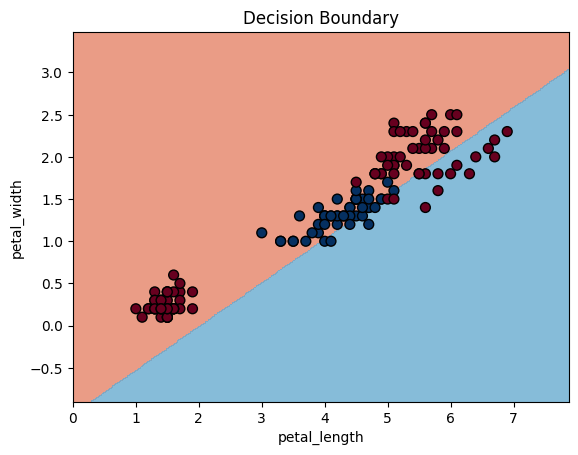

Precision : 0.4
Recall score : 0.2222222222222222


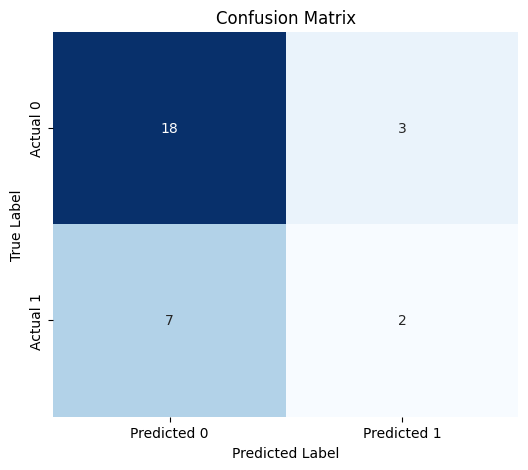

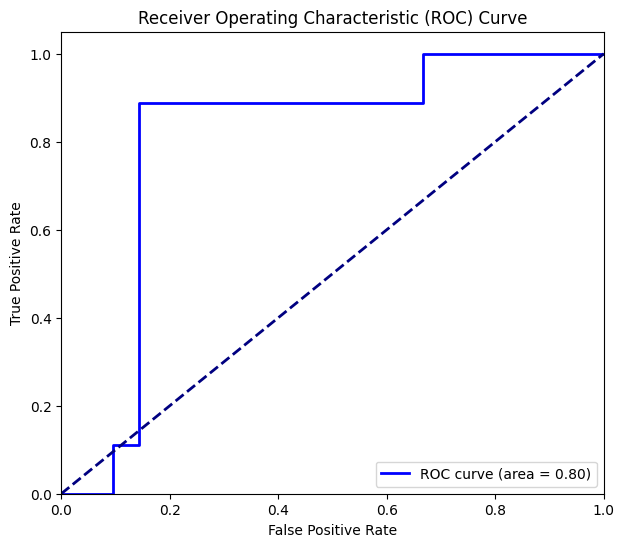

****************End******************


In [196]:
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('iris_dataset.csv')
# print (data)
X=data.drop('species',axis=1)
# print(X)
y=data['species']
species=["Iris-setosa","Iris-virginica","Iris-versicolor"]
# print (y)
for  specie in species:
    y1=(y==specie)

    X_train, X_test, y_train, y_test = train_test_split(X, y1, test_size=0.2, random_state=42)
    model = LinearSVC(C=10,random_state=42)
    result=model.fit(X_train, y_train)
    y_pred=result.predict(X_test)
    print(f"Prediction : {y_pred}")
    # accuracy= model.score(X_test, y_test)
    # print(accuracy)
    print (specie)
    precision=precision_score(y_test, y_pred)
    print(f"precision : {precision}")
    recal = recall_score(y_test, y_pred)
    print(f"Recall : {recal}")
    x_min, x_max = X["petal_length"].min()-1, X["petal_length"].max()+1
    y_min, y_max = X["petal_width"].min()-1, X["petal_width"].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
    plt.scatter(X['petal_length'], X['petal_width'], c=y1, cmap=plt.cm.RdBu, s=50, edgecolors='k')
    plt.xlabel('petal_length')
    plt.ylabel('petal_width')
    plt.title('Decision Boundary')
    plt.show()
    conf=confusion_matrix(y_test, y_pred)
    # print(confu)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', cbar=False,xticklabels=['Predicted 0', 'Predicted 1'],yticklabels=['Actual 0', 'Actual 1'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    # disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Reds)
    # disp.plot()
    # plt.show()

    decision_scores = model.decision_function(X_test)
    fpr, tpr, thresholds = roc_curve(y_test, decision_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()
    print("**********************Standard Scaler***************************")
    scaler = StandardScaler()
    X_train_scaled =scaler.fit_transform(X_train, y_train)
    X_test_scaled = scaler.transform(X_test)
    X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X, y1, test_size=0.2, random_state=42)
    model = LinearSVC(random_state=42)
    result=model.fit(X_train_scaled, y_train)
    y_pred=result.predict(X_test_scaled)
    print(f"Prediction : {y_pred}")
    x_min, x_max = X["petal_length"].min()-1, X["petal_length"].max()+1
    y_min, y_max = X["petal_width"].min()-1, X["petal_width"].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
    plt.scatter(X['petal_length'], X['petal_width'], c=y1, cmap=plt.cm.RdBu, s=50, edgecolors='k')
    plt.xlabel('petal_length')
    plt.ylabel('petal_width')
    plt.title('Decision Boundary')
    plt.show()
    precision=precision_score(y_test, y_pred)
    print(f"Precision : {precision}")
    recal = recall_score(y_test, y_pred)
    print(f"Recall score : {recal}")
    conf=confusion_matrix(y_test, y_pred)
    # print(confu)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', cbar=False,xticklabels=['Predicted 0', 'Predicted 1'],yticklabels=['Actual 0', 'Actual 1'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    # disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Reds)
    # disp.plot()
    # plt.show()
    decision_scores = model.decision_function(X_test)
    fpr, tpr, thresholds = roc_curve(y_test, decision_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()


    # roc= roc_auc_score(y_test, y_pred)
    # print(f"Roc auc score: {roc}")
    # # print(X_train_scaled)


    print("****************End******************")